## RAPID Timeseries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime

## TO DO
# add salinity!
# use that seal formatting pretty thing from GDA

In [3]:
# pretty colors !!!

import math
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle


def plot_colortable(colors, *, ncols=4, sort_colors=True):

    cell_width = 212
    cell_height = 22
    swatch_width = 48
    margin = 12

    # Sort colors by hue, saturation, value and name.
    if sort_colors is True:
        names = sorted(
            colors, key=lambda c: tuple(mcolors.rgb_to_hsv(mcolors.to_rgb(c))))
    else:
        names = list(colors)

    n = len(names)
    nrows = math.ceil(n / ncols)

    width = cell_width * ncols + 2 * margin
    height = cell_height * nrows + 2 * margin
    dpi = 72

    fig, ax = plt.subplots(figsize=(width / dpi, height / dpi), dpi=dpi)
    fig.subplots_adjust(margin/width, margin/height,
                        (width-margin)/width, (height-margin)/height)
    ax.set_xlim(0, cell_width * ncols)
    ax.set_ylim(cell_height * (nrows-0.5), -cell_height/2.)
    ax.yaxis.set_visible(False)
    ax.xaxis.set_visible(False)
    ax.set_axis_off()

    for i, name in enumerate(names):
        row = i % nrows
        col = i // nrows
        y = row * cell_height

        swatch_start_x = cell_width * col
        text_pos_x = cell_width * col + swatch_width + 7

        ax.text(text_pos_x, y, name, fontsize=14,
                horizontalalignment='left',
                verticalalignment='center')

        ax.add_patch(
            Rectangle(xy=(swatch_start_x, y-9), width=swatch_width,
                      height=18, facecolor=colors[name], edgecolor='0.7')
        )

    return fig

In [4]:
# define filepath
central_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/FIELD/RAPID D3 retrieval/CENTRAL_D3retrieval.CSV"
ballpark_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/FIELD/RAPID D3 retrieval/BALLPARK_D3retrieval.CSV"
barge_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/FIELD/RAPID D3 retrieval/BARGE_D3retrieval.CSV"
abbyroad_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/FIELD/RAPID D3 retrieval/ABBYROAD_D3retrieval.CSV"
eyeclinic_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/FIELD/RAPID D3 retrieval/EYECLINIC_D3retrieval.CSV"
riverdale_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/FIELD/RAPID D3 retrieval/RIVERDALE_D3retrieval.CSV"
vet_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/FIELD/RAPID D3 retrieval/VET_D3retrieval.CSV"
waterstreet_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/FIELD/RAPID D3 retrieval/WATERSTREET_D3retrieval.CSV"

# read file
central_df = pd.read_csv(central_file)
ballpark_df = pd.read_csv(ballpark_file)
barge_df = pd.read_csv(barge_file)
abbyroad_df = pd.read_csv(abbyroad_file)
eyeclinic_df = pd.read_csv(eyeclinic_file)
riverdale_df = pd.read_csv(riverdale_file)
vet_df = pd.read_csv(vet_file)
waterstreet_df = pd.read_csv(waterstreet_file)

# compile
df_array = [central_df, ballpark_df, barge_df, abbyroad_df, eyeclinic_df, riverdale_df, vet_df, waterstreet_df]
df_ID_num = [34, 10, 29, 27, 36, 32, 16, 24]
df_names = ["Central Ave", "Ballpark", "Barge Restaurant", "Abby Road", "Eye Clinic", "Riverdale", "Vet", "Water Street"] 
NAVD88offset = [2.486, 3.679, 3.501, 4.441, 3.78, 4.49, 3.68, 3.559] # in m

In [5]:
# Handle NOAA met data

# define met filepath and read file and COMPILE MET DATA
nov25met_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/Data Visualization/TokePointNovMet.csv"
dec25met_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/Data Visualization/TokePointDecMet.csv"
janhalf26met_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/Data Visualization/TokePointHalfJanMet.csv"

nov25met_df = pd.read_csv(nov25met_file)
dec25met_df = pd.read_csv(dec25met_file)
janhalf26met_df = pd.read_csv(janhalf26met_file)

met_df = pd.concat([nov25met_df, dec25met_df, janhalf26met_df], ignore_index=True) # LST time and metric
met_df["Datetime"] = pd.to_datetime(met_df["Date"].astype(str) + " " + met_df["Time (LST)"].astype(str), errors="coerce")
met_df = met_df.set_index("Datetime").sort_index()
met_df["Baro (Pa)"] = pd.to_numeric(met_df["Baro (mb)"], errors='coerce') * 100

# Convert to numeric and to Pa
met_df["Baro (Pa)"] = pd.to_numeric(met_df["Baro (mb)"], errors='coerce') * 100

# Create 5-minute baseline using Pa
met_df_5min = met_df['Baro (Pa)'].resample('5min').interpolate(method='linear')


def itp_noaa_metdata(met_5min_series, sensor_dt_array): 
    """
    Interpolate NOAA atm pressure from 5-min baseline to sensor timestamps

    Parameters:
    - NOAA meteorological dataframe interpolated to 5-min intervals
    - sensor datetime array

    Returns:
    - array of pressure values interpolated at sensor timestamps

    """

    sensor_dt = pd.DatetimeIndex(sensor_dt_array)
    all_times = met_5min_series.index.union(sensor_dt).unique().sort_values()
    combo = met_5min_series.reindex(all_times).interpolate(method="linear")
    
    itp_pressure = combo.loc[sensor_dt]

    return itp_pressure


## Example usage: (add later bc datetime created in for loop)

# sensor_datetimes = central_df['datetime']
# interpolated_pressure = itp_noaa_metdata(met_df_5min, sensor_datetimes)
# # add to sensor dataframe:
# central_df['noaa_pressure'] = interpolated_pressure.values
# # check
# central_df.tail()

In [6]:
# Handle density conversion 
# Add salinity!

def density(T, S=30): # assuming constant salinity for now
    """
    input: temperature array in deg celsius, constant salinity of 30 PSU
    output: density in kg/m^3
    """
    rho_fw = 1000 * (1 - ((T + 288.9414)/(508929.2*(T + 68.12963))) * (T - 3.9863)**2) # empirical fit for rho_fw(T)
    rho_ew = rho_fw + (0.824 * S)
    return rho_ew

In [68]:
# redefine array

df_array = [ballpark_df, barge_df, eyeclinic_df, vet_df, waterstreet_df]
df_ID_num = [10, 29, 36, 16, 24]
df_names = ["Ballpark", "Barge Restaurant", "Eye Clinic", "Vet", "Water Street"] 
NAVD88offset = [3.679, 3.501, 3.78, 3.68, 3.559] # in m

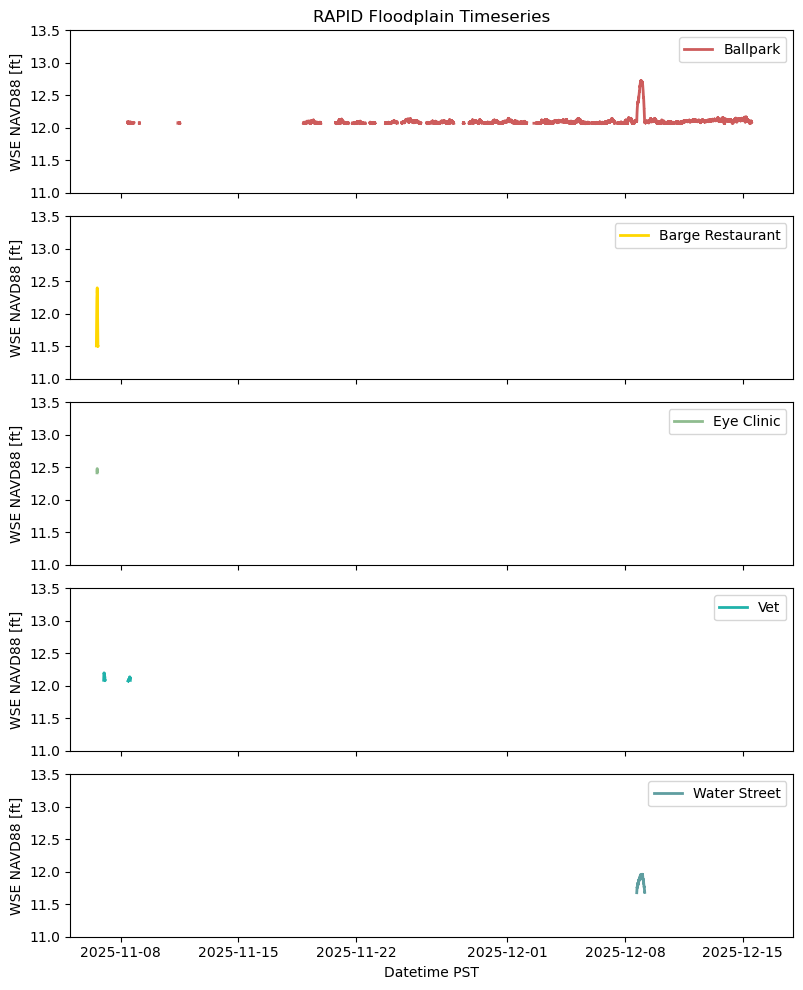

In [90]:
fig, ax = plt.subplots(len(df_array), 1, figsize=(8, 2 * len(df_array)), sharex=True, sharey=True)
ax[0].set_title("RAPID Floodplain Timeseries")

color_array = ["indianred", "gold", "darkseagreen", "lightseagreen", "cadetblue", "steelblue", "cornflowerblue", "orchid"]
start_date = datetime(2025, 11, 5)
end_date = datetime(2025, 12, 18)

for i in range(len(df_array)):
    # define datetime array
    df_array[i]["datetime"] = pd.to_datetime(df_array[i][f"W.G. Num: {df_ID_num[i]}"].astype(str) + " " + df_array[i]["Timestamp"].astype(str),
                            format="%Y/%m/%d %H:%M:%S:%f", errors="coerce")
    dt = df_array[i]["datetime"]
    # define direct parameters
    pressure_mbar = df_array[i]["Pressure [mbar]"]
    temp = df_array[i]["Temp [deg C]"]
    battery_vdc = df_array[i]["Battery [VDC]"]
    # define water level (meters)
    g = 9.80665
    df_array[i]["pressure_pa"] = pressure_mbar * 100
    df_array[i]["rho"] = density(temp, S=30)
    
    sensor_datetimes = df_array[i]['datetime']
    interpolated_pressure = itp_noaa_metdata(met_df_5min, sensor_datetimes)
    df_array[i]['noaa_pressure'] = interpolated_pressure.values
    
    df_array[i]["water_level"] = (df_array[i]["pressure_pa"] - df_array[i]['noaa_pressure']) / (df_array[i]["rho"] * g)
    df_array[i]["water_level"] = np.where(df_array[i]["water_level"] < 0, np.nan, df_array[i]["water_level"])
    
    waterlevel = df_array[i]["water_level"] + NAVD88offset[i]
    waterlevel_ft_navd88 = waterlevel * 3.28084

    # plot on subplot
    ax[i].plot(dt, waterlevel_ft_navd88, color=color_array[i], label=df_names[i], lw=2)
    ax[i].set_xlim(start_date, end_date)
    ax[i].set_ylim(11, 13.5)
    ax[i].set_ylabel("WSE NAVD88 [ft]")
    ax[i].legend(loc="upper right")

ax[-1].set_xlabel("Datetime PST")

plt.tight_layout()